# STANDARD: participants, acquisition history and branch decisions

**UTC throughout.** The participant snapshot is **2026-09-16 00:44:57 UTC**, block **64,089,150**. A separate observed auction follow-up ends **01:14:41 UTC**, block **64,106,912**. These are frozen observations, not live prices.

This notebook answers: who bought/sold, what inventory sellers used, how Charter owners funded actual new branches, and which participant choices could sustain or reverse selling. Addresses are not identified people. Scenarios are conditional; they do not establish calibrated probabilities or a uniquely optimal selling time.

[Findings](PARTICIPANTS.md) · [Method and reproduction](PARTICIPANT_METHOD.md) · [Raw evidence](strategy-current/)

In [1]:
from pathlib import Path
import io, contextlib, json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
from participant_flows import analyze, ROOT, read
from participant_decisions import run
from participant_followup import run as followup
from participant_publication import build
# Everything below runs offline from public pinned data.
with contextlib.redirect_stdout(io.StringIO()):
    attribution = analyze()
    decisions = run()
    latest = followup()
report = build()
out = ROOT / 'participant-results'
display(pd.Series({k: attribution[k] for k in ['snapshot_utc','block','transfer_logs','canonical_swaps','integer_supply_reconciled','all_collected_wallet_balances_reconciled']}))

snapshot_utc                                2026-09-16T00:44:57+00:00
block                                                        64089150
transfer_logs                                                  213702
canonical_swaps                                                 49945
integer_supply_reconciled                                        True
all_collected_wallet_balances_reconciled                         True
dtype: object

## 1. Actual buys and sells, and attribution coverage

Pool ETH is the canonical leg of a trade, before sell-hook deductions / after buy-hook accounting. Routed noncanonical legs are excluded. We reconstruct token-owning endpoints rather than label a router or transaction bundler as the investor. Ambiguous transactions remain in the denominator and are exported separately. Window boundaries use interpolated timestamps between pinned headers; exact blocks and hashes are retained.

In [2]:
windows = pd.read_csv(out/'windows.csv')
display(windows[['window_hours','from_utc_approx','to_utc','side','all_pool_eth','attributed_pool_eth','attribution_fraction','addresses','new_to_canonical_pool_buy_eth']])
cohorts = pd.read_csv(out/'cohorts.csv')
display(cohorts)

,window_hours,from_utc_approx,to_utc,side,all_pool_eth,attributed_pool_eth,attribution_fraction,addresses,new_to_canonical_pool_buy_eth
0,0.333333,2026-09-16T00:24:57+00:00,2026-09-16T00:44:57+00:00,buy,7.804431,7.668670,0.982605,13,1.738299
1,0.333333,2026-09-16T00:24:57+00:00,2026-09-16T00:44:57+00:00,sell,193.347748,193.331670,0.999917,38,0.000000
2,2.000000,2026-09-15T22:44:57+00:00,2026-09-16T00:44:57+00:00,buy,246.967814,246.472518,0.997994,166,130.351396
3,2.000000,2026-09-15T22:44:57+00:00,2026-09-16T00:44:57+00:00,sell,301.061381,300.816417,0.999186,105,0.000000
4,6.000000,2026-09-15T18:44:57+00:00,2026-09-16T00:44:57+00:00,buy,321.780453,319.879413,0.994092,239,162.588163
5,6.000000,2026-09-15T18:44:57+00:00,2026-09-16T00:44:57+00:00,sell,644.396240,642.769562,0.997476,335,0.000000
6,12.000000,2026-09-15T12:44:57+00:00,2026-09-16T00:44:57+00:00,buy,1407.128197,1229.631269,0.873859,864,538.016952
7,12.000000,2026-09-15T12:44:57+00:00,2026-09-16T00:44:57+00:00,sell,2214.519331,2133.028317,0.963201,807,0.000000
8,24.000000,2026-09-15T00:44:57+00:00,2026-09-16T00:44:57+00:00,buy,13438.981016,13140.527862,0.977792,7574,13140.527862
9,24.000000,2026-09-15T00:44:57+00:00,2026-09-16T00:44:57+00:00,sell,10981.250541,10813.819773,0.984753,4006,0.000000


,cohort,addresses,wallet_tokens,native_eth_observed,native_eth_missing,buy_eth_6h,sell_eth_6h,buy_tokens_6h,sell_tokens_6h,branches,pending_tokens
0,charter_operator,941,9.455882e+06,2539.168994,0,41.797105,47.992812,3.475346e+05,3.926735e+05,1099,1.408520e+06
1,inactive_or_unattributed,15381,5.027059e+07,2739.131797,8391,0.000000,0.000000,0.000000e+00,0.000000e+00,0,0.000000e+00
2,net_buyer,191,4.476054e+06,545.637664,7,234.527143,0.531905,1.884688e+06,4.713813e+03,0,0.000000e+00
3,net_seller,284,2.399911e+06,459.152127,156,13.852455,560.633493,1.112609e+05,4.658074e+06,0,0.000000e+00
4,two_way_trader,35,1.429808e+05,32.486133,7,29.702710,33.611352,2.439765e+05,2.752511e+05,0,0.000000e+00


## 2. Sellers' acquisition histories and remaining inventory

Sale provenance uses pro-rata inventory accounting. A transfer preserves upstream acquisition lineage but does not establish that the two addresses share an owner. Canonical and two verified secondary-pool purchases are distinguished from branch mints, genesis allocations and unresolved custody outflows. Unknown cost basis is not treated as zero.

The largest seller's four exits each sold 25% of its then-remaining balance. Its inventory came from previous market purchases. See full trade hashes and precise timestamp flags in `participant-results/trades.csv.gz`.

In [3]:
wallets = pd.read_csv(out/'wallets.csv.gz')
cols = ['address','cohort','charter_count','wallet_tokens','native_eth','buy_pool_eth_6h','sell_pool_eth_6h']
display(wallets.nlargest(12,'sell_pool_eth_6h')[cols])
display(pd.read_csv(out/'sell-provenance.csv').query('window_hours == 6'))
display(pd.Series({k: decisions[k] for k in ['recent_selling_addresses','recent_sellers_zero_balance','recent_seller_remaining_tokens','inactive_inventory_tokens']}))

,address,cohort,charter_count,wallet_tokens,native_eth,buy_pool_eth_6h,sell_pool_eth_6h
1413,0x14b33822c8bc5689e4130b0d3fca676674fb6718,net_seller,0,312861.722216,0.075694,0.000000,79.463207
2419,0x2444429b617062858c0b789608bf0e9fae313db3,net_seller,0,0.000000,0.000000,0.000000,45.471449
10720,0xa1e1a2d159166a85a5e1f7142146013b93968c5b,net_seller,0,0.000000,108.256588,0.000000,43.071091
2458,0x24e7a8963c07dc0ad58098172ab2b9826bc90fb2,net_seller,0,200000.000000,57.963228,9.263570,33.187162
12614,0xbebbad0b95ed88e6c56c8d79daa82257e97c3f44,net_seller,0,0.000000,NaN,0.000000,33.083213
6024,0x5b0051e4ea8eaf6ec523ab2aa76fe0149e68b040,net_seller,0,0.000000,NaN,0.000000,28.426511
10372,0x9c8ff2cb10eb8306c98765ae3f9b2e8a4c6233ee,charter_operator,1,0.000000,19.864724,0.000000,25.124398
16501,0xfb0d8b94027c5109ae89c5f08b025cc598cf6f49,net_seller,0,0.000000,NaN,0.000000,25.008515
135,0x016be7a3ef30cec10f87ecb8c794fe8533c9dddf,net_seller,0,0.000000,NaN,0.000000,14.095359
12281,0xb9e98a981adc50aacc93625990b86a6524c3d3e7,net_seller,0,0.000000,0.000000,3.520805,12.123810


,window_hours,source,sold_tokens,share_of_attributed_sold_tokens
18,6.0,own_pool_buy,4.349471e+06,0.815927
19,6.0,transferred_pool_buy,3.085870e+05,0.057889
20,6.0,branch_withdrawal,0.000000e+00,0.000000
21,6.0,transferred_branch_withdrawal,0.000000e+00,0.000000
22,6.0,initial_allocation,0.000000e+00,0.000000
23,6.0,transferred_allocation,0.000000e+00,0.000000
24,6.0,other_custody_or_unresolved,6.046754e+05,0.113432
25,6.0,own_other_pool_buy,6.448121e+04,0.012096
26,6.0,transferred_other_pool_buy,3.497249e+03,0.000656


recent_selling_addresses          3.350000e+02
recent_sellers_zero_balance       2.570000e+02
recent_seller_remaining_tokens    2.771447e+06
inactive_inventory_tokens         5.027059e+07
dtype: float64

## 3. Buyers and operators are distinct groups

A Charter owner may speculate with wallet tokens while leaving its branch running. “Net buyer”, “net seller” and “two-way trader” describe the last six hours, not permanent motives. Zero or missing native ETH does not prove inability to buy: wrapped assets, stablecoins and external inflows are not fully measured. Owner inventory is shared across its Charters, never duplicated.

In [4]:
display(wallets.nlargest(10,'buy_pool_eth_6h')[cols])
deposits = pd.read_csv(out/'bank-deposits.csv')
display(deposits.groupby('owner_deposit').agg(events=('tx','count'),tokens=('tokens','sum')))
funding = pd.read_csv(out/'license-funding.csv')
display(funding.query('hours_after_reset <= 8'))

,address,cohort,charter_count,wallet_tokens,native_eth,buy_pool_eth_6h,sell_pool_eth_6h
10789,0xa2ee0d9d3da9b93aea50418b25a2c68d03d3fa94,net_buyer,0,376751.504298,0.070437,48.216000,0.000000
9489,0x8f5369de2ca0c17a722c43d1e02ee9ac7a16c763,net_buyer,0,437363.975701,0.357719,35.726277,0.000000
7415,0x6f97b7de6be7b7771e975e46bae96c35e332e172,charter_operator,2,251715.071940,4.555188,24.646934,0.000000
2635,0x27d25ebe6637e4b173ec7d0546cd54d1b74828e0,net_buyer,0,138373.533244,0.059256,16.814847,0.000000
97,0x00fbfab3a2941a0a6450a731c5f90e3ac8d48265,two_way_trader,0,0.000000,15.103579,9.800000,10.000234
13305,0xc90d95d2ae793ad128ef3c3e4892a195afe6af7b,net_buyer,0,78486.922867,20.000715,9.800000,0.000000
2458,0x24e7a8963c07dc0ad58098172ab2b9826bc90fb2,net_seller,0,200000.000000,57.963228,9.263570,33.187162
1995,0x1d7b4a9960f908ecc71405f74715fd7f05bf5581,charter_operator,1,281578.976049,29.890809,8.477995,0.000000
6907,0x681d22c5e615c7a876026ceba3dc36c6dde5b97d,net_buyer,0,164883.352217,3.002178,8.428000,0.000000
4476,0x431f15623676d6617859794f18dc3d0681c9ec00,net_buyer,0,137749.444432,0.000000,7.388564,0.000000


,events,tokens
owner_deposit,,
True,158,1.920922e+06


,hours_after_reset,elapsed_days,timestamp_utc,unit_price_tokens,use_existing_wallet_inventory,licenses_funded,entirely_internal_licenses,wallet_tokens_used,fresh_tokens_needed,fresh_ETH_if_shortfall_bought_now
0,0,0.013275,2026-09-16T01:04:04+00:00,23776.681858,False,100,16,0.000000e+00,1.551215e+06,186.458644
1,0,0.013275,2026-09-16T01:04:04+00:00,23776.681858,True,100,16,1.867636e+06,0.000000e+00,0.000000
2,4,0.179942,2026-09-16T05:04:04+00:00,12525.283604,False,100,38,0.000000e+00,5.307317e+05,61.684509
3,4,0.179942,2026-09-16T05:04:04+00:00,12525.283604,True,100,38,6.973402e+05,0.000000e+00,0.000000
4,8,0.346609,2026-09-16T09:04:04+00:00,6899.584477,False,100,64,0.000000e+00,1.019672e+05,11.688563
5,8,0.346609,2026-09-16T09:04:04+00:00,6899.584477,True,100,64,1.506902e+05,0.000000e+00,0.000000


## 4. The branches actually sold: later evidence

This section is **post-snapshot observation**, not a forecasting backtest. Bank deposits are token burns into an internal ledger; licenses then spend that ledger. Depositing old inventory and spending internal rewards do not force a contemporaneous pool purchase.

The first checkpoint at 01:09:32 UTC recorded 50 licenses and a 6.4% token rebound. The next checkpoint at 01:14:41 recorded 51 licenses, renewed selling and only a 1.2% gain from the original snapshot. The ownership and funding tables below show how much demand actually came from the expanding operators.

timestamp_utc                                                         2026-09-16T01:14:41+00:00
block                                                                                  64106912
block_hash                                    0x17ec75c40b4d92423b1f7d6989ecbca1183cd4eeae97...
from_snapshot_utc                                                     2026-09-16T00:44:57+00:00
new_licenses                                                                                 51
license_cost_tokens                                                              1208848.742215
bank_deposit_tokens                                                              1147844.707397
deposit_existing_wallet_tokens                                                    998656.687879
deposit_new_canonical_tokens                                                      107073.302859
deposit_new_other_custody_tokens                                                   42114.716659
new_withdrawals                         

,charter_id,cost_tokens,prior_bank_balance,new_issuance,prefunded_wallet_tokens,new_canonical_tokens,new_other_custody_tokens,tx
0,160,23770.183734,23765.985135,4.198600,0.000000,0.0,0.000000,0x4e0cde3c91ec506658fa46960c6290164009043b5dc8...
1,298,23765.852694,13140.539922,17.042923,9939.488216,0.0,668.781633,0x25b5ca51cb3b671df4db4992efe10ca07c9982a5b888...
2,160,23763.687487,23759.406347,4.281140,0.000000,0.0,0.000000,0x094de192c3ac932ef263b520b8313c80a97fa7737419...
3,497,23761.522488,23758.833141,2.689347,0.000000,0.0,0.000000,0x218ec9076f644fcd8051a7423a214849963f2babfe54...
4,686,23760.440066,1265.202203,17.116585,22478.121279,0.0,0.000000,0x89c0649064f36a9a4dd963bd570ab166279f0ce02b7a...
5,712,23759.357697,629.818546,8.568869,23120.970282,0.0,0.000000,0x395f976b635460144d76f0bd888229211b1b635bec80...
6,918,23757.193115,629.789197,8.580244,23118.823674,0.0,0.000000,0x38bf4de5046e6583213976d21b902071ee4c7af140eb...
7,501,23755.028741,23752.327641,2.701100,0.000000,0.0,0.000000,0x7869ca4cc0ee427ae75b1332359a969744d62fdf95d2...
8,277,23755.028741,629.831304,8.595522,23116.601916,0.0,0.000000,0xc3af482c3cd1a35f313946b39d36f783f600e4c6e25a...
9,946,23751.782571,629.615811,8.618993,23113.547767,0.0,0.000000,0xce002218bd078f91627a0cf3d995dd9ad43b78a4e122...


side  bought_license_in_window
buy   False                       205.388828
      True                         23.433760
sell  False                       204.227413
      True                          2.993576
Name: canonical_ETH, dtype: float64

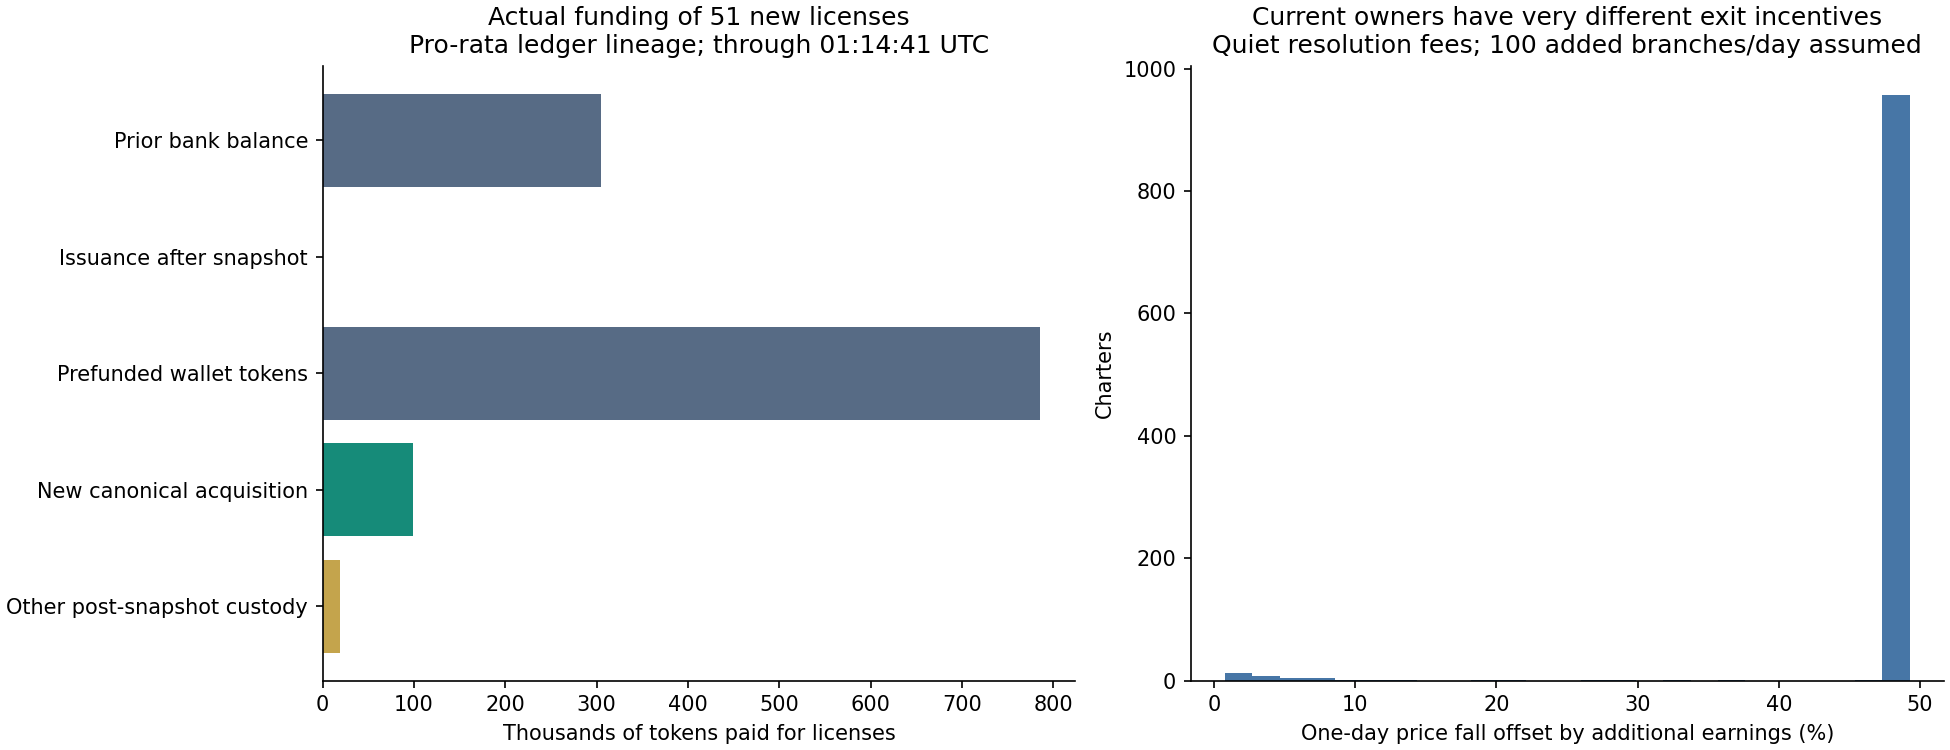

In [5]:
display(pd.Series(latest))
display(pd.read_csv(out/'followup-license-funding.csv').head(12))
display(pd.read_csv(out/'followup-trades.csv').groupby(['side','bought_license_in_window']).canonical_ETH.sum())
display(Image(filename=str(out/'branch-funding-and-incentives.png')))

## 5. Rational choices depend on the participant's balance

Compare executable ETH proceeds today with expected executable proceeds later, including issuance, dilution, resolution fees, market taxes and slippage. In general **E[quantity × price] is not E[quantity] × E[price]**; price and issuance can move together.

The one-day threshold table uses each actual Charter. A small earned balance can grow rapidly relative to its size; a large prefunded balance cannot. Quiet versus heavy future withdrawal pressure changes the fee tradeoff.

The separate 14-day optimal-full-retirement grid is a horizon sensitivity, **not a complete optimal policy**. Partial exits, a branch's value beyond the horizon, future auctions and policy changes are omitted. An endpoint maximum is censored. Actual license purchases show why a short horizon with no continuing branch value cannot explain every owner's choice. Do not infer zero demand or irrationality from that restriction.

In [6]:
thresholds = pd.read_csv(out/'branch-hold-thresholds.csv')
display(thresholds.groupby('future_exit_pressure').one_day_max_price_fall.describe())
display(thresholds.query("future_exit_pressure == 'quiet'").nsmallest(12,'one_day_max_price_fall'))
stopping = pd.read_csv(out/'branch-decisions.csv')
display(stopping.groupby('assumed_daily_price_fall').agg(median_full_exit_day=('optimal_full_exit_day_within_14d','median'),horizon_censored=('exit_horizon_censored','sum')))
display(pd.read_csv(out/'recovery-hurdles.csv'))

,count,mean,std,min,25%,50%,75%,max
future_exit_pressure,,,,,,,,
1m_gross_bank_exits,999.0,-0.284045,0.195529,-1.417366,-0.245280,-0.245280,-0.245280,-0.243028
quiet,999.0,0.475804,0.080007,0.007923,0.491664,0.491664,0.491664,0.492533


,charter_id,owner,branches,pending_tokens,daily_tokens_now,net_exit_ETH_now,future_exit_pressure,one_day_break_even_price_ratio,one_day_max_price_fall,future_resolution_fee,elapsed_days,timestamp_utc
992,497,0x8a43c0d6dd0ef5a28e22835fcb645930faee2221,1,75630.259284,636.942675,7.835739,quiet,0.992077,0.007923,0.024523,1,2026-09-17T00:44:57+00:00
1000,501,0xeed2a31a29f91f3f148235fcc66fad810803d72a,1,75630.259284,636.942675,7.835739,quiet,0.992077,0.007923,0.024523,1,2026-09-17T00:44:57+00:00
910,456,0xa4a5cc8c29353f333d031f7df7a717ef86caa7de,1,53935.129284,636.942675,5.602798,quiet,0.988881,0.011119,0.022574,1,2026-09-17T00:44:57+00:00
318,160,0xcab21d30dbbe7ef86618e1aea139f6c8a9b44c98,1,48115.259284,636.942675,5.001301,quiet,0.987542,0.012458,0.022144,1,2026-09-17T00:44:57+00:00
526,264,0x6ba9ad599e6271252817933831e3148936cf742a,1,26550.899284,636.942675,2.765138,quiet,0.977592,0.022408,0.020893,1,2026-09-17T00:44:57+00:00
1678,841,0xeb456428815f395e6f02d4982f5521116c89c620,2,49263.611069,1273.885350,5.120061,quiet,0.975955,0.024045,0.022270,1,2026-09-17T00:44:57+00:00
1558,780,0x2fbbbcd93cd7036c732d90ab8ffe7757e1310eb6,1,24410.259284,636.942675,2.542612,quiet,0.975670,0.024330,0.020798,1,2026-09-17T00:44:57+00:00
1448,725,0x338188207e6256f0179b110d7f7bbce5a838f8ad,1,24153.959284,636.942675,2.515963,quiet,0.975418,0.024582,0.020787,1,2026-09-17T00:44:57+00:00
188,95,0x338188207e6256f0179b110d7f7bbce5a838f8ad,1,23630.259284,636.942675,2.461507,quiet,0.974886,0.025114,0.020765,1,2026-09-17T00:44:57+00:00
614,308,0x9f84fcd4528e85301892b7396cb50408ac56e7ee,1,22917.259284,636.942675,2.387359,quiet,0.974123,0.025877,0.020735,1,2026-09-17T00:44:57+00:00


,median_full_exit_day,horizon_censored
assumed_daily_price_fall,,
-0.10,14.000000,999
0.00,14.000000,999
0.05,12.250000,0
0.15,4.125000,0
0.30,1.583333,0
0.50,0.416667,0


,target_price_ratio,target_ETH_per_token,fresh_buy_ETH_no_sellers
0,1.050000,0.000116,88.480977
1,1.100000,0.000122,175.093115
2,1.250000,0.000139,422.475623
3,1.500000,0.000166,795.258900
4,1.731844,0.000192,1117.323248


## 6. Which flows produce recovery or further decline?

These are **six-hour stress paths from the earlier snapshot**, ending 06:44:57 UTC, not updated predictions conditional on the observed auction. Seller continuation is bounded by remaining tokens. Replacement-selling volume and new-entry capacity come from observed participants; persisting them is still an assumption. Buyers have finite measured native-ETH budgets and a visible reservation-price gate.

`observed_replacement` maintains first-sale volume; `seller_exhaustion` removes replacement sellers; `renewed_entry` sustains the stronger last-two-hour arrival rate; `broader_holder_exit` doubles replacement volume. Licenses and bank exits are assessed in the actual-follow-up and owner-decision sections, rather than added as unverified automatic flows. No likelihood weights are assigned. The later burst of buying and its reversal demonstrate why these paths must not be marketed as exact top predictions.

,scenario,hours,end_utc,end_price_ratio,recent_seller_tokens_sold,replacement_seller_tokens_sold,inactive_inventory_sale_fraction,new_buyer_capacity_ETH_hour,repeat_buyer_capacity_ETH_6h,actual_buy_ETH,actual_sell_tokens
0,seller_exhaustion,6,2026-09-16T06:44:57+00:00,1.026328,1.823438e+06,0.000000e+00,0.000000,27.651048,87.508635,253.414923,1.823438e+06
1,observed_replacement,6,2026-09-16T06:44:57+00:00,0.861559,1.823438e+06,3.064721e+06,0.060964,27.651048,87.508635,253.414923,4.888159e+06
2,renewed_entry,6,2026-09-16T06:44:57+00:00,0.974213,1.823438e+06,3.064721e+06,0.060964,66.505814,87.508635,486.543522,4.888159e+06
3,broader_holder_exit,6,2026-09-16T06:44:57+00:00,0.732256,1.823438e+06,6.129442e+06,0.121929,27.651048,87.508635,253.414923,7.952880e+06


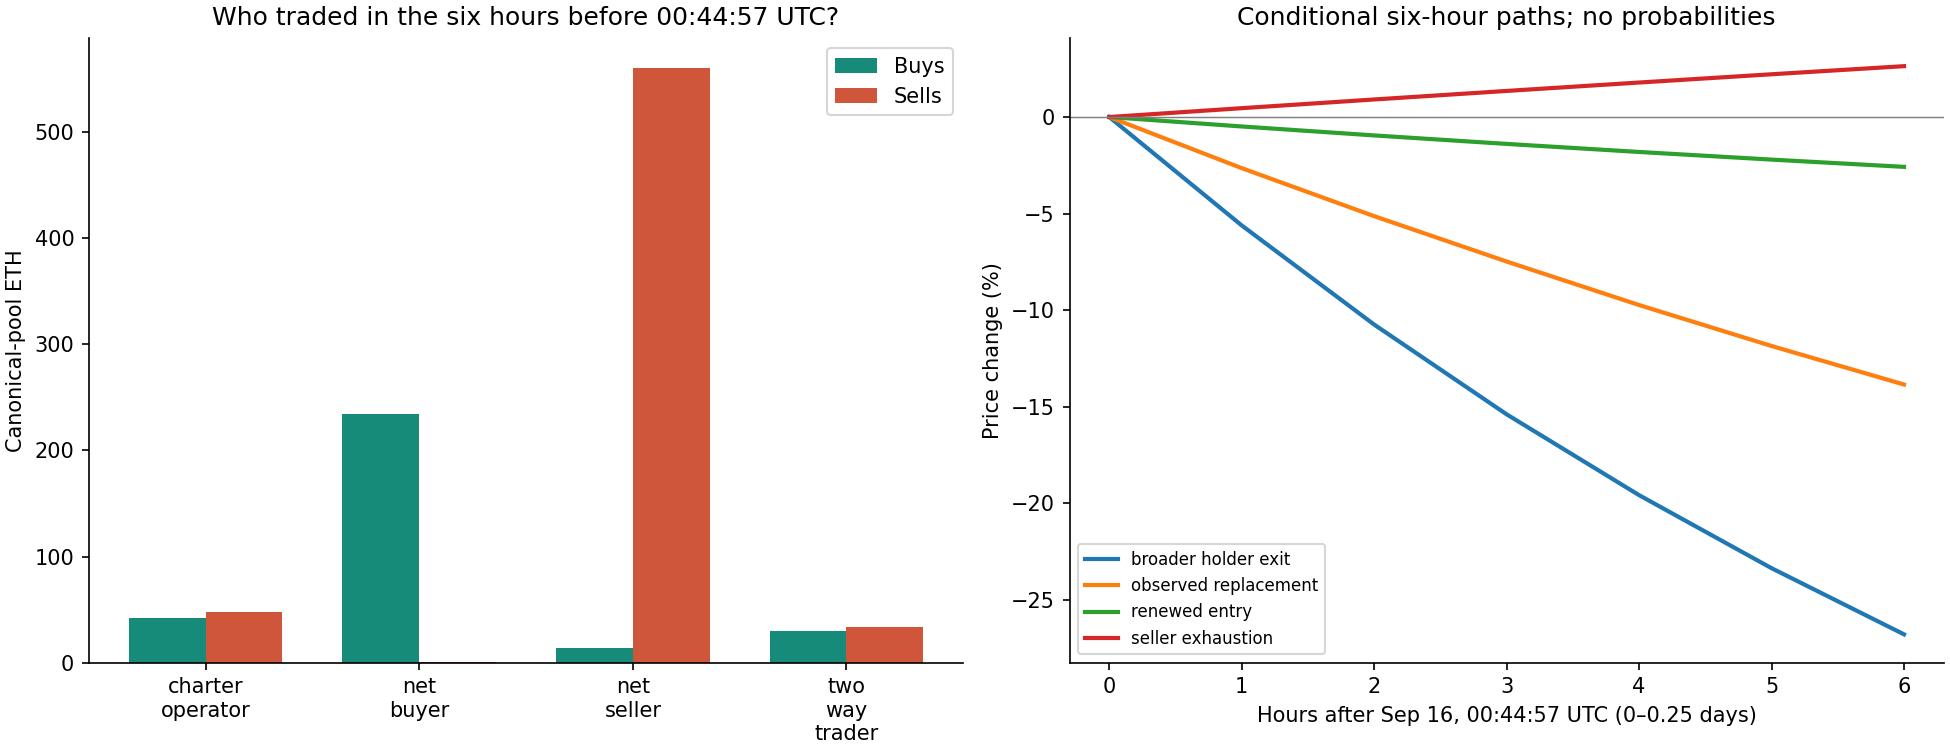

,ETH_error,token_error
scenario,,
broader_holder_exit,5.115908e-13,5.587935e-09
observed_replacement,1.421085e-12,1.117587e-08
renewed_entry,4.263256e-13,1.117587e-08
seller_exhaustion,1.421085e-12,4.656613e-10


In [7]:
display(pd.read_csv(out/'conditional-scenarios.csv'))
display(Image(filename=str(out/'participant-flows-and-paths.png')))
paths = pd.read_csv(out/'conditional-paths.csv')
display(paths.groupby('scenario')[['ETH_error','token_error']].max())

## 7. What to monitor next

- New selling addresses and the inventory they control; do not extrapolate depleted sellers forever.
- Canonical net ETH buying after the license-opening burst.
- Whether remaining licenses are funded with new acquisitions, existing wallet tokens or bank balances.
- Charter owners retiring branches versus merely selling separately held tokens.
- The remaining license quota, falling auction price, dilution and resolution-fee pressure.
- Noncanonical route activity and unmeasured capital; one wallet address is not necessarily one person.

Locked protocol liquidity stays in the model, but selling removes ETH from it. A burn can reduce future sale inventory without adding a new market bid. The evidence supports an observed fragile rebound; it does not uniquely identify the next price path or the final top.